In [33]:
%pip install numpy pandas matplotlib python-pptx

In [1]:
import sys  # noqa
# sys.path.append('/workspace/forecasting_simulation')  # noqa

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import seaborn as sns 
import matplotlib.colors as mcolors
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from utilss import * 

## Load the Data

In [2]:
import pandas as pd

# Load the data
data = pd.read_excel('book2.xlsx')
data['datetime'] = pd.to_datetime(data['datetime'])  # Ensure datetime is in correct format

# Check the number of columns in the DataFrame
num_columns = data.shape[1]

# Column indices: 8th column (index 7) for kwh and 9th column (index 8) for kw
kwh_column_idx = 7  # 8th column (0-based index)
kw_column_idx = 8   # 9th column (0-based index)

# Check datetime interval to determine if it's 5-minute or 1-hour data
time_diff = data['datetime'].diff().dt.total_seconds().median()
frequency = 12 if time_diff == 300 else 1  # 5-minute interval if median diff is 300 seconds, otherwise 1 hour

# Handling 5-minute data
if frequency == 12:  # 5-minute interval
    print("Data is 5-minute interval.")

    # Check if there are 8 or 9 columns
    if num_columns == 8:
        # Check if the 8th column is named as 'kw'
        if data.columns[kwh_column_idx].lower() == 'kw':
            # Rename it to 'kwh' and create 'kw' as the 9th column
            data.rename(columns={data.columns[kwh_column_idx]: 'kwh'}, inplace=True)
            data['kw'] = data['kwh'] * 12  # Create the 9th column by multiplying kwh by 12
        else:
            # If it's already kwh, just create 'kw' column
            data['kw'] = data.iloc[:, kwh_column_idx] * 12  # Create the 9th column by multiplying kwh by 12
            data.rename(columns={data.columns[kwh_column_idx]: 'kwh'}, inplace=True)
            
        # Ensure the data has 9 columns now
        print(f"Data now has {data.shape[1]} columns (9 columns expected).")

    elif num_columns == 9:
        # Simply rename the 8th and 9th columns as kwh and kw
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', data.columns[kw_column_idx]: 'kw'}, inplace=True)

# Handling 1-hour data
elif frequency == 1:  # 1-hour interval
    print("Data is 1-hour interval.")

    # Check if there are 8 or 9 columns
    if num_columns == 8:
        # Copy the value from the 8th column (kwh) to the 9th column (kw)
        data['kw'] = data.iloc[:, kwh_column_idx]
        # Rename the columns appropriately
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', 'kw': 'kw'}, inplace=True)
        print(f"Data now has {data.shape[1]} columns (9 columns expected).")

    elif num_columns == 9:
        # Ensure the 8th and 9th columns are the same
        if not (data.iloc[:, kwh_column_idx] == data.iloc[:, kw_column_idx]).all():
            print("Warning: 8th and 9th columns do not match.")
        # Rename the columns as kwh and kw
        data.rename(columns={data.columns[kwh_column_idx]: 'kwh', data.columns[kw_column_idx]: 'kw'}, inplace=True)

# Show first few rows to verify the results
print(data.head())

Data is 5-minute interval.
Data now has 9 columns (9 columns expected).
  supply period            datetime       date  correct hour  hour  weekday  \
0        May-24 2024-04-26 00:00:00 2024-04-26             0     1        4   
1        May-24 2024-04-26 00:05:00 2024-04-26             0     1        4   
2        May-24 2024-04-26 00:10:00 2024-04-26             0     1        4   
3        May-24 2024-04-26 00:15:00 2024-04-26             0     1        4   
4        May-24 2024-04-26 00:20:00 2024-04-26             0     1        4   

        wesm    kwh      kw  
0   5.594433  30.26  363.12  
1  28.014230  30.26  363.12  
2  11.711672  30.26  363.12  
3  10.466232  30.71  368.52  
4   5.575092  30.71  368.52  


In [3]:
# Load your data
data = pd.read_excel('Primepack Processed LP (Nov23-Aug24) - 1 hour data.xlsx')

# Process the data
processed_data = load_data(data)

# Display the processed data
print(processed_data.head())

  supply period            datetime       date  correct hour  hour  weekday  \
0        Nov-23 2023-10-26 00:00:00 2023-10-26             0     1        3   
1        Nov-23 2023-10-26 01:00:00 2023-10-26             1     2        3   
2        Nov-23 2023-10-26 02:00:00 2023-10-26             2     3        3   
3        Nov-23 2023-10-26 03:00:00 2023-10-26             3     4        3   
4        Nov-23 2023-10-26 04:00:00 2023-10-26             4     5        3   

       wesm      kwh       kw  
0  4.014980  473.072  473.072  
1  3.317417  468.176  468.176  
2  3.243580  481.504  481.504  
3  2.836222  450.608  450.608  
4  3.327357  468.496  468.496  


In [4]:
# Check the columns in your data
print(data.columns)

Index(['supply period', 'datetime', 'date', 'correct hour', 'hour', 'weekday',
       'wesm', 'kwh', 'kw'],
      dtype='object')


In [5]:
# Generate energy summary
energy_summary = generate_energy_summary(data, kwh_column='kwh', kw_column='kw')
energy_summary

,supply period,number of hours,kwh,kw,load factor
0,Nov-23,744.00,"179,221.30",481.50,50.03
1,Dec-23,720.00,"124,587.34",472.00,36.66
2,Jan-24,744.00,"153,757.78",582.48,35.48
3,Feb-24,744.00,"157,732.64",510.24,41.55
4,Mar-24,696.00,"154,084.93",534.14,41.45
5,Apr-24,744.00,"113,829.09",435.92,35.10
6,May-24,720.00,"129,662.76",427.38,42.14
7,Jun-24,744.00,"140,826.75",515.85,36.69
8,Jul-24,720.00,"133,670.02",540.08,34.38
9,Aug-24,744.00,"161,292.67",518.58,41.81


## Plot Energy behavior

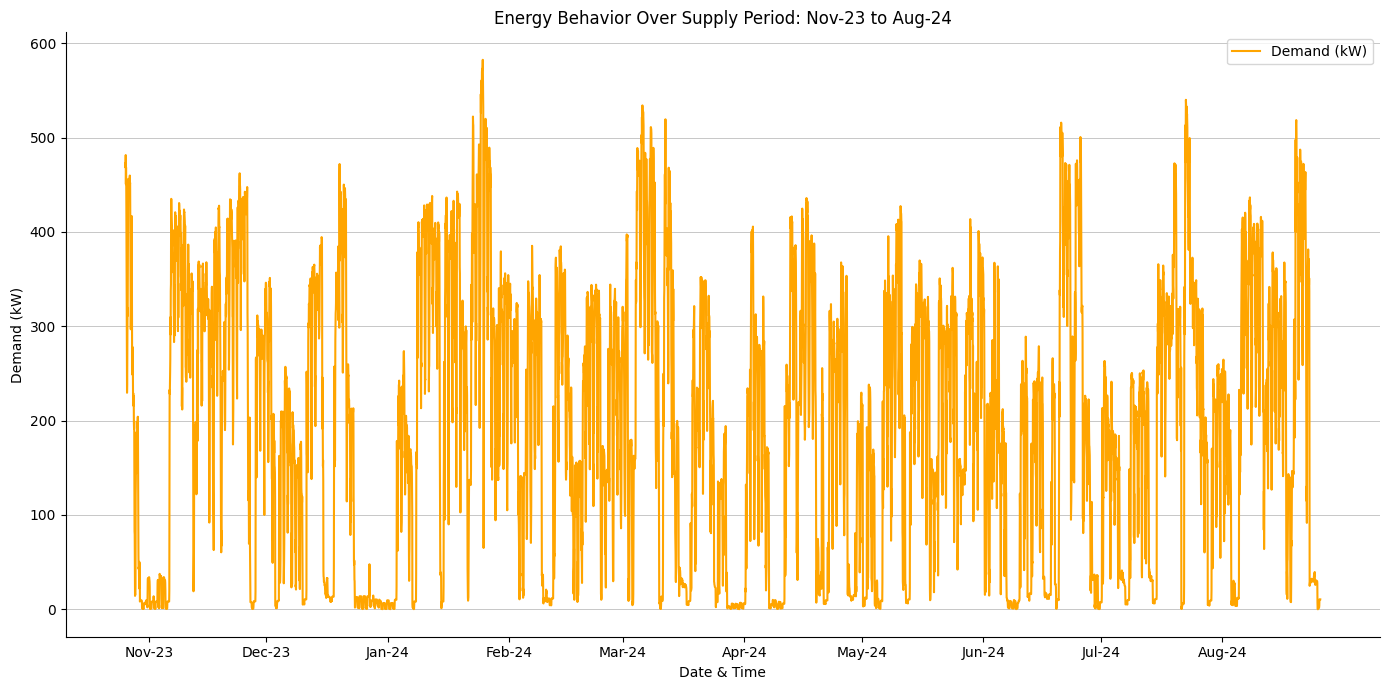

In [6]:
# Call the function to plot
energy_behavior_plot(data)

c:\Users\MARK\Insights_Automation\utilss.py:259: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['kwh'] = monthly_data['kwh'].str.replace(',', '').astype(float)
c:\Users\MARK\Insights_Automation\utilss.py:260: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  monthly_data['kw'] = monthly_data['kw'].str.replace(',', '').astype(float)


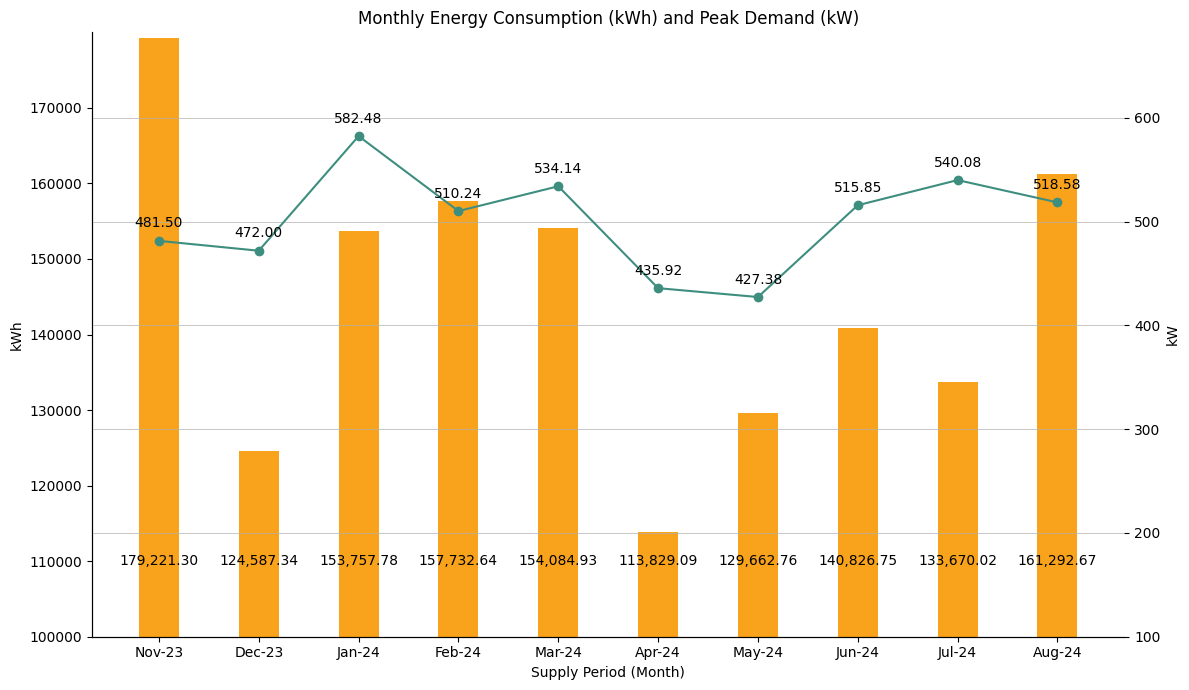

In [7]:
save_energy_consumption_plot(energy_summary)

In [8]:
# Use the function with the energy summary data
transposed_table = loadfactor_table(energy_summary)

# Display the transposed table
transposed_table

supply period,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24
load factor,50.03%,36.66%,35.48%,41.55%,41.45%,35.1%,42.14%,36.69%,34.38%,41.81%


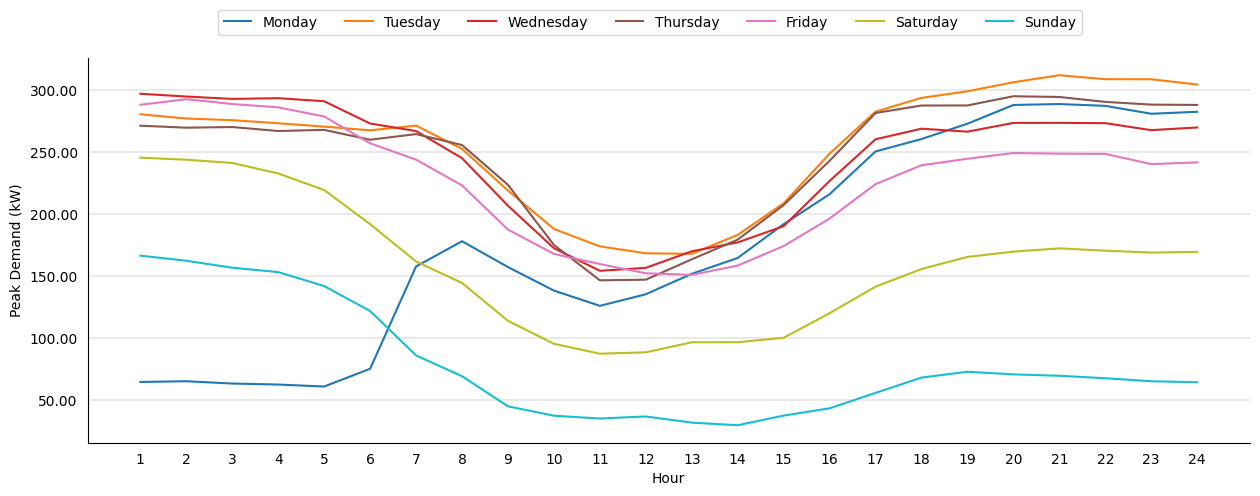

In [9]:
# Average by Hour
hourly_load_curve_by_day = data.pivot_table(
  index="hour",
  columns="weekday",
  values="kw",
  aggfunc={
    "kw": "mean"
  }
)
 
# Convert from kW to MW
# hourly_load_curve_by_day = hourly_load_curve_by_day / 1000
 
# Get list of days of the week
days_of_week = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
 
plot_hourly_by_day_load_curve(hourly_load_curve_by_day, column_name='max', unit='kW')

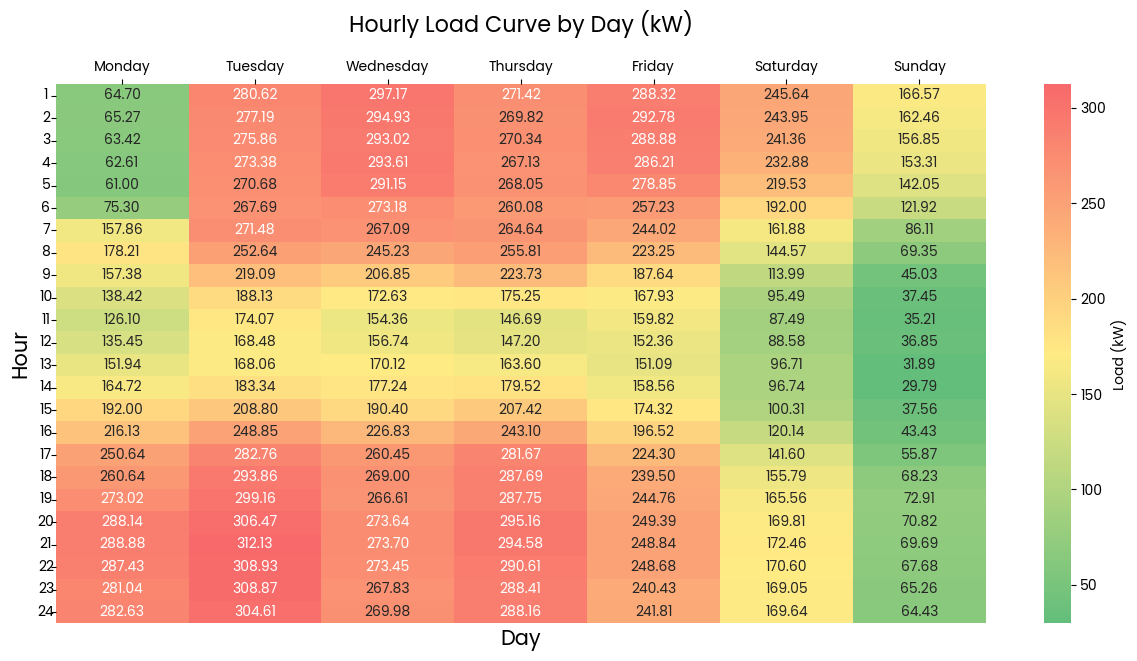

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.colors as mcolors

# Define the new color map based on the provided colors
cmap = mcolors.LinearSegmentedColormap.from_list(
    "", ["#63BE7B", "#FFEB84", "#F8696B"]  # Custom colors for the heatmap
)

# Define weekday labels
weekday_labels = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Display the hourly load curve by day as a heatmap table with the new color map
def display_hourly_by_day_table(hourly_by_day_summary):
    plt.figure(figsize=(15, 7))
    ax = sns.heatmap(
        hourly_by_day_summary,
        annot=True,
        fmt=".2f",
        cmap=cmap,  # Use the updated colormap
        cbar_kws={'label': 'Load (kW)'}
    )
    
    # Move x-axis labels to the top
    ax.xaxis.set_ticks_position('top')
    
    # Set custom labels for the x-axis on top with centered alignment
    ax.set_xticks(np.arange(len(weekday_labels)) + 0.5)
    ax.set_xticklabels(weekday_labels, rotation=0, ha='center')

    # Rotate y-axis (hour) labels to make them vertical
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='center')
    
    plt.xlabel("Day", fontsize=15)  # X-axis title at the top
    plt.ylabel("Hour", fontsize=15)  # Y-axis title

    plt.title("Hourly Load Curve by Day (kW)", fontsize=16, pad=20)  # Add padding to title
    #Save the plot as an image
    plt.savefig('hourly_load_Curve.png')
    plt.show()

# Use the function to display the table as a heatmap
display_hourly_by_day_table(hourly_load_curve_by_day)


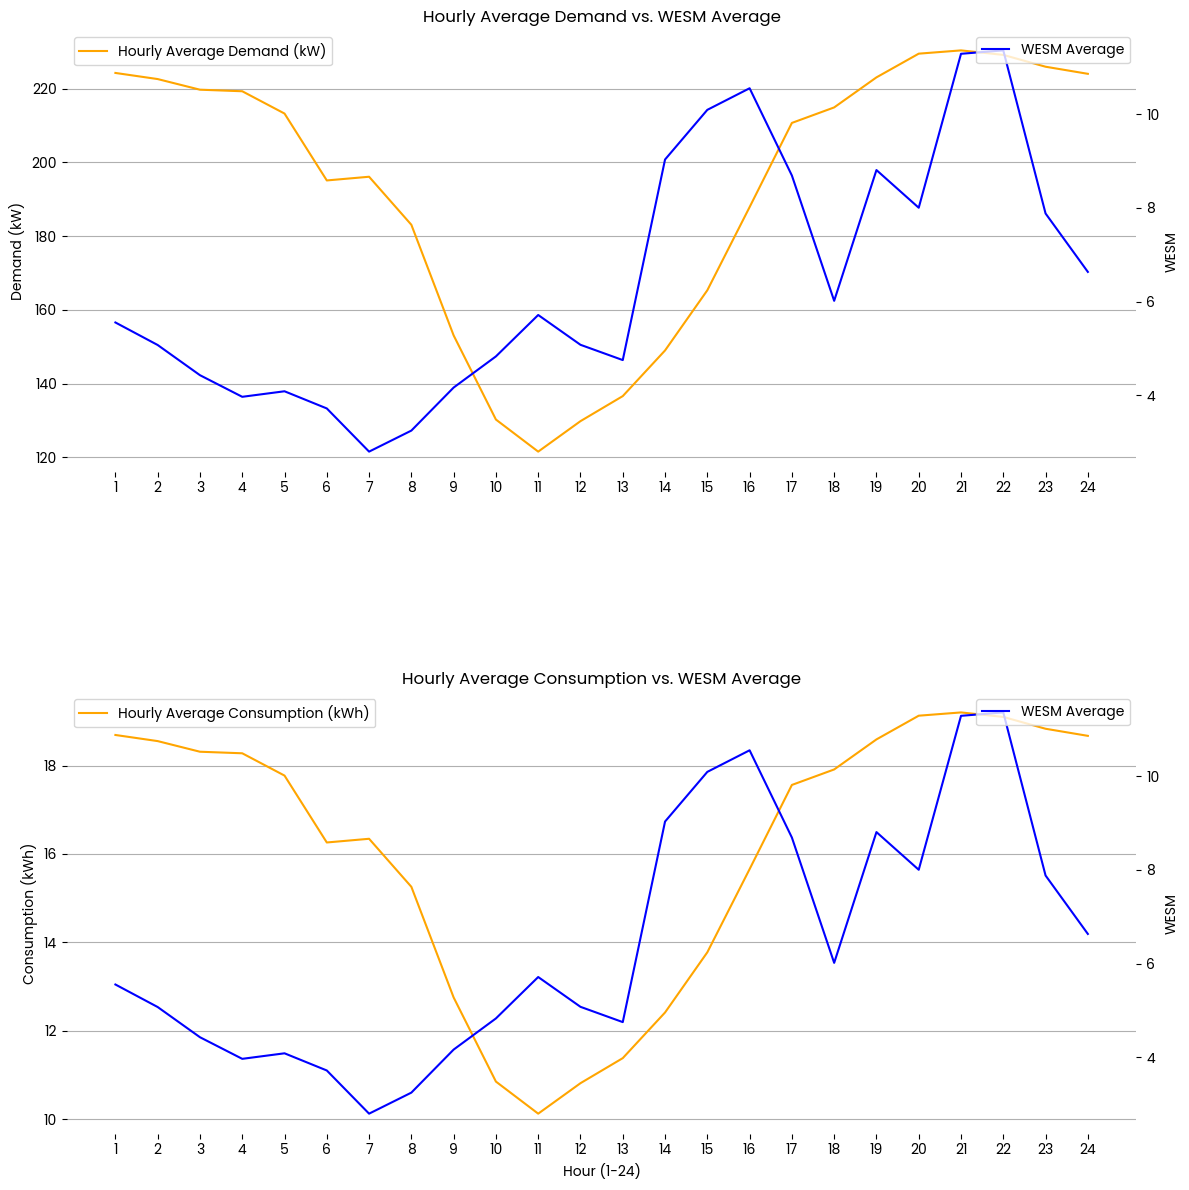

In [16]:
plot_demand_and_consumption_WESM(data)

In [17]:
generate_daily_kw_report(data)

,Hour,Mean,Max,Min,Sum,% of Consumption,WESM
0,1,224.2921,533.6960,6.0160,"328,363.6320",4.8392%,5.5526
1,2,222.6300,532.0320,5.8880,"325,930.3200",4.8034%,5.0713
2,3,219.7443,498.6240,5.8880,"321,705.6480",4.7411%,4.4266
3,4,219.3232,511.0800,5.8880,"321,089.2080",4.7320%,3.9650
4,5,213.2709,521.6400,5.8240,"312,228.5280",4.6015%,4.0831
5,6,195.1174,512.0400,1.5600,"285,651.9360",4.2098%,3.7163
6,7,196.1207,449.4000,0.2400,"287,120.6400",4.2314%,2.7940
7,8,183.0834,437.0400,0.0000,"268,034.0400",3.9501%,3.2434
8,9,153.0540,436.1600,0.0000,"224,071.1280",3.3022%,4.1627
9,10,130.2256,441.4800,0.0000,"190,650.2160",2.8097%,4.8280


In [14]:
import os
from pptx.util import Inches, Pt
from pptx.dml.color import RGBColor
from pptx.enum.text import PP_ALIGN
from pptx import Presentation
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Get the current working directory where the Jupyter notebook is running (or script)
current_dir = os.getcwd()

# Define relative paths based on the current directory
template_path = os.path.join(current_dir, 'solx.pptx')
output_path = os.path.join(current_dir, 'Generated_Presentation3.pptx')
plot_image_path = os.path.join(current_dir, 'energy_consumption_plot.png')

# Load the PowerPoint template
ppt = Presentation(template_path)
title_slide_layout = ppt.slide_layouts[0]  # Title slide
content_slide_layout = ppt.slide_layouts[1]  # Content slide
section_slide_layout = ppt.slide_layouts[3]  # Section slide
two_content_slide_layout = ppt.slide_layouts[4]  # Two content slide

In [ ]:
# Function to add a table with content to a PowerPoint slide
def add_table_to_slide(slide, data, rows, cols, x, y, width, height):
    table = slide.shapes.add_table(rows, cols, x, y, width, height).table
    
    # Adjust column width for the first column
    table.columns[0].width = Inches(2.2)

    # Define the row header color (using RGB)
    row_header_color = RGBColor(249, 163, 28)

    # Rename the columns
    new_column_names = {
        'supply period': 'Supply Period',
        'number of hours': 'Total Hours',
        'kwh': 'Consumption(kWh)',
        'kw': 'Demand(kW)',
        'load factor': 'Load Factor'
    }
    
    # Add header with orange background and white font
    for col_idx, col_name in enumerate(data.columns):
        new_name = new_column_names.get(col_name.lower(), col_name)  # Get the new name if available
        cell = table.cell(0, col_idx)
        cell.text = str(new_name)
        cell.fill.solid()
        cell.fill.fore_color.rgb = RGBColor(249, 163, 28)  # Orange
        cell.text_frame.paragraphs[0].font.color.rgb = RGBColor(255, 255, 255)  # White
        cell.text_frame.paragraphs[0].font.size = Pt(12)  # Header font size
        cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER
    
    # Fill table with data and adjust font size for each cell
    for row_idx, row_data in enumerate(data.values):
        for col_idx, cell_value in enumerate(row_data):
            cell = table.cell(row_idx + 1, col_idx)  # +1 to skip the header row
            cell.text = str(cell_value)
            cell.text_frame.paragraphs[0].font.size = Pt(10)  # Font size for content
            cell.text_frame.paragraphs[0].alignment = PP_ALIGN.CENTER

        # Bold the rows for 'Total', 'Average', 'Max', 'Min'
        if row_data[0] in ['Total', 'Average', 'Max', 'Min']:
            for col_idx in range(cols):
                cell = table.cell(row_idx + 1, col_idx)
                cell.text_frame.paragraphs[0].font.bold = True  # Make the text bold

    return table

# Add a new slide with content layout
slide2 = ppt.slides.add_slide(content_slide_layout)
slide2.shapes.title.text = "Monthly kW, kWh Comparison & Load Factor​"

# Add the energy summary table to the slide
add_table_to_slide(slide2, energy_summary, rows=len(energy_summary)+1, cols=len(energy_summary.columns), 
                   x=Inches(0.4), y=Inches(2.0), width=Inches(13), height=Inches(5))

slide3 = ppt.slides.add_slide(content_slide_layout)
slide3.shapes.title.text = "Monthly Energy Consumption (kWh) and Peak Demand (kW)"
slide3.shapes.add_picture('energy_consumption_plot.png',
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(12), height= Inches(5))
# pic = slide.shapes.add_picture('energy_consumption.png', left, top, height=Inches(5.5))

#Add 
slide4 = ppt.slides.add_slide(content_slide_layout)
slide4.shapes.title.text = "Monthly Energy Consumption (kWh) and Peak Demand (kW)"
slide4.shapes.add_picture('hourly_load_Curve.png',
                         left= Inches(0.4), top= Inches(2),
                         width= Inches(12), height= Inches(5))
# pic = slide.shapes.add_picture('energy_consumption.png', left, top, height=Inches(5.5))

# Save the new presentation
ppt.save(output_path)
